### **Project: YAKWETU™ Climate-Based Variable Pricing Model**

#### **1. Project Overview**

This notebook presents an end-to-end analysis of the YAKWETU™ Climate-Based Variable Pricing Project. The core objective is to develop a data-driven framework for the MyMovies.Africa™ platform that leverages the influence of climate (weather) patterns on user content consumption behavior. By integrating historical weather data with platform usage data, we aim to analyze viewing behavior, predict periods of high engagement, and simulate variable pricing strategies. This approach supports more personalized user experiences and optimizes monetization strategies for YAKWETU™ Online Ltd..

#### **2. Business Problem**

YAKWETU™ Online Ltd. distributes African content globally via its MyMovies.Africa™ platform. As the platform grows, there is a need for data-driven strategic decisions regarding pricing and content engagement. Global evidence suggests that weather patterns can influence user mood and content consumption behavior. This project addresses the challenge of creating a flexible pricing strategy that capitalizes on these climate-driven demand fluctuations.

#### **3. Project Goals**

The primary goals of this project are to:
* Integrate historical weather data with platform usage data.
* Identify correlations between weather conditions and content engagement.
* Use machine learning to predict high-demand and low-demand periods.
* Simulate pricing strategies based on forecasted conditions.
* Provide actionable recommendations for content scheduling and pricing.

### **4. Setup & Imports**

This section initializes the environment by importing the necessary libraries for data manipulation, analysis, and database connectivity. We will start with core libraries and then establish a connection to our MySQL database.

In [1]:
# Imports and DB Config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')
import mysql.connector
import requests
import time
import ipaddress
import logging
import os 
from datetime import datetime, timedelta
from datetime import timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier

### **5. Database Connection and Data Loading**

This section establishes a connection to the MySQL database to load the `combined_user_activity` table. It also performs initial data preparation and cleaning steps, such as converting date and time columns to the correct format, to ensure the data is ready for analysis.

### **5.1. Database Configuration**

This cell defines the connection parameters for the MySQL database.

In [2]:
# Database connection details 
DB_CONFIG = {
    'host': 'localhost',
    'user': 'root',
    'password': '9715xjon',
    'database': 'working_db',
    'port': 3306
}

# Initialize DataFrames 
df_activity = pd.DataFrame()
df_weather = pd.DataFrame()
df_activity_with_weather = pd.DataFrame()

### **5.2. Connect to Database and Load Activity Data**

We will now connect to the MySQL database and load the `combined_user_activity` table into a pandas DataFrame.

In [3]:
# Establish the connection
cnx = mysql.connector.connect(**DB_CONFIG)
if cnx.is_connected():
    print("Successfully connected to the database.")
else:
    print("Failed to connect to the database.")
    raise ConnectionError("Database connection failed.")

# Fetching the combined user activity table
query_activity = "SELECT * FROM combined_user_activity;"
df_activity = pd.read_sql(query_activity, cnx)

Successfully connected to the database.


### **5.3. Initial Data Inspection**

This step verifies that the data has been loaded correctly by displaying the first few rows and the DataFrame's column information.

In [4]:
# Display the first few rows of the DataFrame and its info
print(df_activity.head())
df_activity.info()

  record_type  activity_id  user_id  content_id    platform  \
0        view           40        1          30  Windows 10   
1        view           38        1          31  Windows 10   
2        view           18        1           7  Windows 10   
3        view           17        1          25     Android   
4        view           12        1           1  Windows 10   

  activity_created_on  currenttime        ipaddress        lasteditedon  \
0 2019-09-30 14:32:41         31.0      154.70.0.67 2020-03-15 16:32:18   
1 2019-09-30 13:29:16        794.0      154.70.0.67 2020-03-15 16:32:18   
2 2019-09-19 16:56:55        728.0      41.90.65.92 2020-03-18 20:29:14   
3 2019-09-17 00:51:53       2613.0      154.70.0.67 2020-03-15 16:32:18   
4 2019-08-23 15:29:37       4685.0  197.237.247.155 2020-03-15 16:32:18   

                   title                                             genres  \
0              SUPA MODO  ["Adventure","Chick Flick","Drama","Fantasy","...   
1           

### **5.4. Data Cleaning and Preprocessing**

We perform initial cleaning steps, including converting relevant columns to the correct datetime format and ensuring consistency in country codes for subsequent merging.

In [5]:
# Convert 'activity_created_on' to datetime objects
df_activity['activity_created_on'] = pd.to_datetime(df_activity['activity_created_on'])

# Convert 'currenttime' and 'lasteditedon' (if they are datetime-like and not already)
for col in ['currenttime', 'lasteditedon']:
    if col in df_activity.columns and df_activity[col].dtype == 'object':
        df_activity[col] = pd.to_datetime(df_activity[col], errors='coerce')
        

# Check if 'country_code' is properly set for merging 
if 'country_code' not in df_activity.columns:
    df_activity['country_code'] = df_activity['locale']

### **5.5. Close Database Connection**

It is good practice to close the database connection once the necessary data has been loaded to free up resources.

In [6]:
if 'cnx' in locals() and cnx.is_connected():
    cnx.close()

### **6. Load and Preprocess Weather Data**
This section focuses on loading the external weather data, performing initial checks, and ensuring the data is in the correct format for later merging with the user activity data.

### **6.1. Load Weather Data**

We will now load the historical climate data from the provided CSV file into a pandas DataFrame.

In [7]:
# Load the weather data from the CSV file using a relative path
csv_file_path = '../data/weather_data.csv'
df_weather = pd.read_csv(csv_file_path)

### **6.2. Initial Weather Data Inspection**

This step verifies that the data has been loaded correctly by displaying the first few rows and the DataFrame's column information.

In [8]:
# Display the first few rows of the DataFrame and its info
print(df_weather.head())
df_weather.info()

         time  temperature_2m_max  temperature_2m_min  \
0  2019-01-01                24.8                13.9   
1  2019-01-02                25.4                14.3   
2  2019-01-03                24.6                15.0   
3  2019-01-04                20.8                15.3   
4  2019-01-05                22.7                13.9   

   apparent_temperature_max  apparent_temperature_min  precipitation_sum  \
0                      25.5                      13.0                0.0   
1                      26.0                      13.7                0.0   
2                      25.0                      14.8                0.1   
3                      21.7                      15.6               13.5   
4                      22.7                      13.9                5.6   

   rain_sum  weathercode  windspeed_10m_max     city  
0       0.0          2.0               14.8  Nairobi  
1       0.0          3.0               15.1  Nairobi  
2       0.1         51.0           

### **6.3. Convert Date Column to Datetime Objects**

The `date` column in the weather data needs to be converted to a proper datetime format to allow for accurate merging with the user activity data. This code checks for common `date` column names and performs the conversion.

In [9]:
# Convert the date column in weather CSV to datetime objects
if 'time' in df_weather.columns:
    df_weather['time'] = pd.to_datetime(df_weather['time'], errors='coerce').dt.date
elif 'date' in df_weather.columns:
    df_weather['date'] = pd.to_datetime(df_weather['date'], errors='coerce').dt.date
elif 'weather_date' in df_weather.columns:
    df_weather['weather_date'] = pd.to_datetime(df_weather['weather_date'], errors='coerce').dt.date
else:
    print("No common date column found in wather CSV for conversion.")

### **6.4. Final Weather Data Inspection**

We will perform a final inspection to confirm that the date column has been successfully converted.

In [10]:
# Checking updated weather information
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9608 entries, 0 to 9607
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   time                      9608 non-null   object 
 1   temperature_2m_max        9599 non-null   float64
 2   temperature_2m_min        9599 non-null   float64
 3   apparent_temperature_max  9599 non-null   float64
 4   apparent_temperature_min  9599 non-null   float64
 5   precipitation_sum         9599 non-null   float64
 6   rain_sum                  9599 non-null   float64
 7   weathercode               9599 non-null   float64
 8   windspeed_10m_max         9599 non-null   float64
 9   city                      9608 non-null   object 
dtypes: float64(8), object(2)
memory usage: 750.8+ KB


### **6.5. Standardize Weather Data Columns**
This section renames the `date` column in the `weather` DataFrame to `weather_date` and adds a `country_code` column based on the city to prepare the data for merging.

In [11]:
# Rename the 'time' column to 'weather_date' for consistency and clearer merge
if 'time' in df_weather.columns:
    df_weather.rename(columns={'time': 'weather_date'}, inplace=True)
elif 'date' in df_weather.columns and 'weather_date' not in df_weather.columns:
    df_weather.rename(columns={'date': 'weather_date'}, inplace=True)
    
# Ensure 'weather_date' is in date format 
if 'weather_date' in df_weather.columns:
        df_weather['weather_date'] = pd.to_datetime(df_weather['weather_date'], errors='coerce').dt.date
    
else:
    print("Weather_date column  not found after renaming.")
    
# Add a 'country_code' column to df_weather based on the 'city' column
if 'city' in df_weather.columns:
    df_weather['country_code'] = df_weather['city'].map({
        'Nairobi': 'KE',
        'Lagos': 'NG',
        'Dubai': 'AE',
        'New York': 'US',
    })
    
else:
    print("'City' column not found in df_weather. Cannot infer 'country_code'.")

### **6.6. Aggregate Weather Data by Country and Date**
Since the user activity data is at a daily granularity per country, this step aggregates the weather data to a single, representative entry per country per day

In [12]:
# Aggregate df_weather by country_code and weather_date
# Define aggregation methods for numerical and categorical columns
aggregation_methods = {
    col: 'mean' for col in df_weather.select_dtypes(include=['number']).columns if col not in ['weathercode']
}
# For weathercode, use mode 
if 'weathercode' in df_weather.columns:
    aggregation_methods['weathercode'] = lambda x: x.mode()[0] if not x.mode().empty else None

# Ensure 'weather_date' and 'country_code' are not included in aggregation values
if 'weather_date' in aggregation_methods:
    del aggregation_methods['weather_date']
if 'country_code' in aggregation_methods:
    del aggregation_methods['country_code']
if 'city' in aggregation_methods: # Remove city from aggregation values, it's a grouping key
    del aggregation_methods['city']

df_weather_aggregated = df_weather.groupby(['country_code', 'weather_date']).agg(aggregation_methods).reset_index()

### **6.7. Final Weather Data Inspection**
This cell replaces the original df_weather with the aggregated version and displays the updated DataFrame information to confirm the changes.

In [13]:
# Replace the original df_weather with the aggregated one for the merge
df_weather = df_weather_aggregated

# Checking the new aggregated DataFrame
print(df_weather.head())
df_weather.info()

  country_code weather_date  temperature_2m_max  temperature_2m_min  \
0           AE   2019-01-01                25.4                15.2   
1           AE   2019-01-02                25.9                15.5   
2           AE   2019-01-03                28.0                14.3   
3           AE   2019-01-04                26.0                17.0   
4           AE   2019-01-05                24.8                16.4   

   apparent_temperature_max  apparent_temperature_min  precipitation_sum  \
0                      26.0                      15.2                0.0   
1                      25.9                      15.0                0.0   
2                      26.9                      12.8                0.0   
3                      25.6                      15.4                0.0   
4                      25.3                      16.0                0.0   

   rain_sum  windspeed_10m_max  weathercode  
0       0.0               16.2          2.0  
1       0.0             

### **7. Merge DataFrames**
This section combines the df_activity and df_weather DataFrames into a single, comprehensive DataFrame (df_activity_with_weather) based on the country_code and date. This integrated dataset is now ready for exploratory data analysis and modeling.

In [14]:
# Merge df_activity and df_weather 
# Ensure 'activity_date' is available in df_activity 
if 'activity_date' not in df_activity.columns:
    df_activity['activity_date'] = df_activity['activity_created_on'].dt.date

# Determine the date column name in df_weather for merging
weather_date_col = None
if 'date' in df_weather.columns:
    weather_date_col = 'date'
elif 'weather_date' in df_weather.columns:
    weather_date_col = 'weather_date'
elif 'time' in df_weather.columns: # Fallback if not renamed yet
    weather_date_col = 'time'
    
if weather_date_col is None:
    print("No suitable date column found in df_weather for merging.")
else:
    df_activity_with_weather = pd.merge(
        df_activity,
        df_weather,
        # Merging only on country_code and date, as city is no longer in df_activity
        left_on=['country_code', 'activity_date'],
        right_on=['country_code', 'weather_date'],
        how='left' # Use left join to keep all activity records
    )

    # Drop the redundant weather date column after merge if it's different from activity_date
    if weather_date_col != 'activity_date' and weather_date_col in df_activity_with_weather.columns:
        df_activity_with_weather = df_activity_with_weather.drop(columns=[weather_date_col])

   # Print the shape and head of the merged DataFrame
    print(df_activity_with_weather.head())
 
    df_activity_with_weather.info()

  record_type  activity_id  user_id  content_id    platform  \
0        view           40        1          30  Windows 10   
1        view           38        1          31  Windows 10   
2        view           18        1           7  Windows 10   
3        view           17        1          25     Android   
4        view           12        1           1  Windows 10   

  activity_created_on  currenttime        ipaddress        lasteditedon  \
0 2019-09-30 14:32:41         31.0      154.70.0.67 2020-03-15 16:32:18   
1 2019-09-30 13:29:16        794.0      154.70.0.67 2020-03-15 16:32:18   
2 2019-09-19 16:56:55        728.0      41.90.65.92 2020-03-18 20:29:14   
3 2019-09-17 00:51:53       2613.0      154.70.0.67 2020-03-15 16:32:18   
4 2019-08-23 15:29:37       4685.0  197.237.247.155 2020-03-15 16:32:18   

                   title  ... country_code  activity_date temperature_2m_max  \
0              SUPA MODO  ...           KE     2019-09-30               28.8   
1         

### **8. Data Quality Check and Cleaning**
This section is dedicated to assessing the quality of the merged data and handling any missing or inconsistent values. We will first check for NaN values and then use appropriate imputation or handling strategies for both categorical and numerical columns

### **8.1. Summary Statistics and Missing Values**

We start by generating descriptive statistics to understand the distribution of our numerical data and checking for the presence of any missing (`NaN`) values.

In [15]:
# Checking the dataframe's summary of statistics
print(df_activity_with_weather.describe())

# Check for any NaN values in the merged DataFrame
print(df_activity_with_weather.isnull().sum())

        activity_id       user_id    content_id  \
count  33839.000000  33839.000000  33839.000000   
mean   13145.250776  12570.020686    120.433760   
min        1.000000      1.000000      1.000000   
25%     4564.000000   7335.000000     86.000000   
50%    12447.000000   9821.000000     99.000000   
75%    21004.500000  18914.500000    164.000000   
max    29512.000000  30003.000000    395.000000   
std     8952.174289   8015.137337     63.824876   

                 activity_created_on   currenttime  \
count                          33839   4690.000000   
mean   2023-12-30 14:42:03.832353024   2635.559915   
min              2019-06-24 16:56:59      0.000000   
25%       2023-09-09 16:29:27.500000    205.250000   
50%              2024-05-24 11:41:55   1453.000000   
75%       2025-02-14 17:02:43.500000   5614.750000   
max              2025-07-25 22:16:40  11110.000000   
std                              NaN   2621.342253   

                        lasteditedon      duration   

### **8.2. Handling Missing Values**

Based on our findings, we will now handle the missing data. For categorical columns, we'll replace `NaN` with 'N/A', and for numerical weather data, we'll use a combination of imputation strategies like zero-filling and median imputation.

In [16]:
# Handling NaN from UNION ALL where NaN means 'Not Applicable'
union_categorical_cols = ['platform', 'ipaddress', 'source', 'currency', 'purchase_type']
for col in union_categorical_cols:
    if col in df_activity_with_weather.columns and df_activity_with_weather[col].dtype == 'object':
        df_activity_with_weather[col] = df_activity_with_weather[col].fillna('N/A')
        print(f"Filled NaN in '{col}' with 'N/A'.")

# Handling NaNs from Weather Data Merge
weather_cols = [
    'temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_max',
    'apparent_temperature_min', 'precipitation_sum', 'rain_sum',
    'weathercode', 'windspeed_10m_max' # Corrected column name
]

# Impute numerical weather columns
for col in weather_cols:
    if col in df_activity_with_weather.columns:
        if df_activity_with_weather[col].isnull().any():
            if 'precipitation' in col or 'rain' in col:
                df_activity_with_weather[col] = df_activity_with_weather[col].fillna(0)
                print(f"Imputed missing '{col}' with 0.")
            elif 'temperature' in col or 'windspeed' in col:
                median_val = df_activity_with_weather[col].median()
                df_activity_with_weather[col] = df_activity_with_weather[col].fillna(median_val)
                print(f"Imputed missing '{col}' with median: {median_val:.2f}.")
            elif 'weathercode' in col:
                mode_val = df_activity_with_weather[col].mode()[0]
                df_activity_with_weather[col] = df_activity_with_weather[col].fillna(mode_val)
                print(f"Imputed missing '{col}' with mode: {mode_val}.")

Filled NaN in 'platform' with 'N/A'.
Filled NaN in 'ipaddress' with 'N/A'.
Filled NaN in 'source' with 'N/A'.
Filled NaN in 'currency' with 'N/A'.
Filled NaN in 'purchase_type' with 'N/A'.
Imputed missing 'temperature_2m_max' with median: 25.10.
Imputed missing 'temperature_2m_min' with median: 15.20.
Imputed missing 'apparent_temperature_max' with median: 26.00.
Imputed missing 'apparent_temperature_min' with median: 15.40.
Imputed missing 'precipitation_sum' with 0.
Imputed missing 'rain_sum' with 0.
Imputed missing 'weathercode' with mode: 51.0.
Imputed missing 'windspeed_10m_max' with median: 13.70.


### **8.3. Understanding the Remaining Missing Values**
After the imputation, we will check for any remaining NaNs. The output below shows that the `amount` column still has 4690 missing values, and the `currenttime` and `lasteditedon` columns have 29149 missing values.

These are a logical outcome of the UNION ALL operation used to create the dataset. Specifically, the `amount` column has missing values because all the `view` records do not have an associated `purchase` value. We will leave amount as it is, as these NaNs are semantically meaningful. We will handle the datetime columns in the next step.

In [17]:
# Check for any NaN values in the merged DataFrame
print(df_activity_with_weather.isnull().sum())

record_type                     0
activity_id                     0
user_id                         0
content_id                      0
platform                        0
activity_created_on             0
currenttime                 29149
ipaddress                       0
lasteditedon                29149
title                           0
genres                          0
duration                        0
content_country                 0
year                            0
locale                          0
purchase_type                   0
amount                       4690
source                          0
currency                        0
country_code                    0
activity_date                   0
temperature_2m_max              0
temperature_2m_min              0
apparent_temperature_max        0
apparent_temperature_min        0
precipitation_sum               0
rain_sum                        0
windspeed_10m_max               0
weathercode                     0
dtype: int64


### **8.4. Handling Missing Datetime Values**
The currenttime and lasteditedon columns have a significant number of missing values. We will handle these by filling them with a consistent value to prevent errors in subsequent calculations, such as the view_minutes feature.

In [18]:
# Fill missing 'currenttime' and 'lasteditedon' values
df_activity_with_weather['currenttime'] = df_activity_with_weather['currenttime'].fillna(0)
df_activity_with_weather['lasteditedon'] = df_activity_with_weather['lasteditedon'].fillna(pd.NaT) # Use NaT for datetime columns

### **9. Feature Engineering and Data Preparation**
This section creates new, relevant features from the existing columns. These features will be used in subsequent analysis and predictive modeling to help us better understand the relationship between weather and user engagement.

In [19]:
df_merged = df_activity_with_weather.copy()

#### **9.1. Create Engagement and Temperature-Based Features**

Here, we transform raw numerical data into more useful features. view_minutes will give us a standardized measure of engagement, is_rainy will simplify our weather analysis into a binary choice, and temp_bin will categorize temperatures to find patterns in user behavior across different climate ranges.

In [20]:
# Create a 'view_minutes' feature from 'currenttime' to quantify user engagement
df_merged['view_minutes'] = df_merged['currenttime'] / 60

# Create a binary 'is_rainy' feature: 1 if precipitation is > 1.0, 0 otherwise
df_merged['is_rainy'] = (df_merged['precipitation_sum'] > 1.0).astype(int)

# Create a categorical 'temp_bin' feature to group temperatures into ranges
df_merged['temp_bin'] = pd.cut(
    df_merged['temperature_2m_max'],
    bins=[-10, 15, 25, 40],
    labels=['cold', 'mild', 'hot']
)

#### **9.2. Create Categorical Weather Features from Weather Code**

The raw weathercode is numerical, which is not intuitive for analysis. This step maps those codes to clear, descriptive categories (e.g., 'Rainy', 'Clear/Cloudy'), making it much easier to correlate weather events with user behavior.

In [21]:
# Define a function to map weather codes to human-readable categories
def map_weathercode_to_condition(code):
    if code in [0, 1, 2, 3]:  # Clear sky, partly cloudy
        return 'Clear/Cloudy'
    elif code in [45, 48]:  # Fog, depositing rime fog
        return 'Foggy'
    elif code in [51, 53, 55, 56, 57, 61, 63, 65, 66, 67, 80, 81, 82]:  # Drizzle, Rain, Rain showers
        return 'Rainy'
    elif code in [71, 73, 75, 77, 85, 86]:  # Snow, snow grains, snow showers
        return 'Snowy'
    elif code in [95, 96, 99]:  # Thunderstorm, thunderstorm with hail
        return 'Thunderstorm'
    else:
        return 'Other'

# Apply the function to the 'weathercode' column to create a new categorical column
df_merged['weather_condition_category'] = df_merged['weathercode'].apply(map_weathercode_to_condition)

# Let's inspect the new feature's value counts
print(df_merged['weather_condition_category'].value_counts())

weather_condition_category
Rainy           25193
Clear/Cloudy     8582
Snowy              64
Name: count, dtype: int64


#### **9.3. Parse Genres for Detailed Analysis**

The 'genres' column is currently a string representation of a list, making it difficult to analyze individual genres. This step is crucial for fulfilling a key project goal by parsing these strings into actual lists. This will allow us to analyze genre popularity by exploding the list, which will be done in the next section.

In [22]:
# Define a function to safely parse the 'genres' string into a list of genres
import ast

def parse_genres(genres_str):
    if isinstance(genres_str, list):
        return genres_str
    if not isinstance(genres_str, str) or genres_str in ('[]', '[""]', ''):
        return []
    try:
        # ast.literal_eval is a safer alternative to eval()
        return ast.literal_eval(genres_str)
    except (ValueError, SyntaxError):
        # Fallback for unexpected string formats
        return [g.strip() for g in genres_str.split(',') if g.strip()]

# Apply the function to the 'genres' column to create the 'genres_list'
df_merged['genres_list'] = df_merged['genres'].apply(parse_genres)

#### **9.4. Verification of New Features**

In [23]:
# Display the first few rows to confirm the new columns were created correctly
print("DataFrame head after feature engineering:")
print(df_merged.head())

# Check the list of columns to ensure all new features are present
print("\nDataFrame columns after feature engineering:")
print(df_merged.columns)

DataFrame head after feature engineering:
  record_type  activity_id  user_id  content_id    platform  \
0        view           40        1          30  Windows 10   
1        view           38        1          31  Windows 10   
2        view           18        1           7  Windows 10   
3        view           17        1          25     Android   
4        view           12        1           1  Windows 10   

  activity_created_on  currenttime        ipaddress        lasteditedon  \
0 2019-09-30 14:32:41         31.0      154.70.0.67 2020-03-15 16:32:18   
1 2019-09-30 13:29:16        794.0      154.70.0.67 2020-03-15 16:32:18   
2 2019-09-19 16:56:55        728.0      41.90.65.92 2020-03-18 20:29:14   
3 2019-09-17 00:51:53       2613.0      154.70.0.67 2020-03-15 16:32:18   
4 2019-08-23 15:29:37       4685.0  197.237.247.155 2020-03-15 16:32:18   

                   title  ... apparent_temperature_min  precipitation_sum  \
0              SUPA MODO  ...                     1

### **10. Exploratory Data Analysis (EDA)**
In this section, we will use visualizations to explore our data, with a focus on understanding the relationship between user activity and weather. We'll start by looking at the distribution of different record types.

#### **10.1. High-Level EDA**
This section provides an initial overview of the dataset, examining the distribution of key categorical features to establish a foundational understanding of user demographics and environmental conditions.

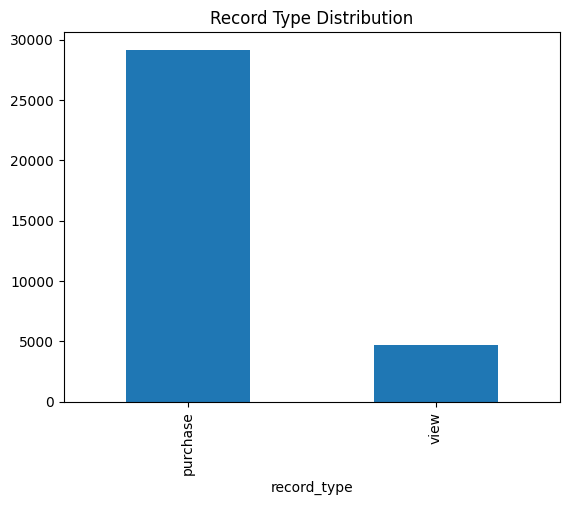

In [24]:
# Record Type Distribution
df_merged['record_type'].value_counts().plot(kind='bar', title='Record Type Distribution')
plt.show()

**Output Summary:**

The bar chart above shows that the dataset contains a significantly higher number of purchase records than view records. This distribution is important to keep in mind, as it may skew any analysis towards purchase-related behavior.

#### **10.1.1 Distribution of New Weather Condition Categories**
To confirm that our new categorical feature was created correctly, we will visualize its distribution using a count plot.

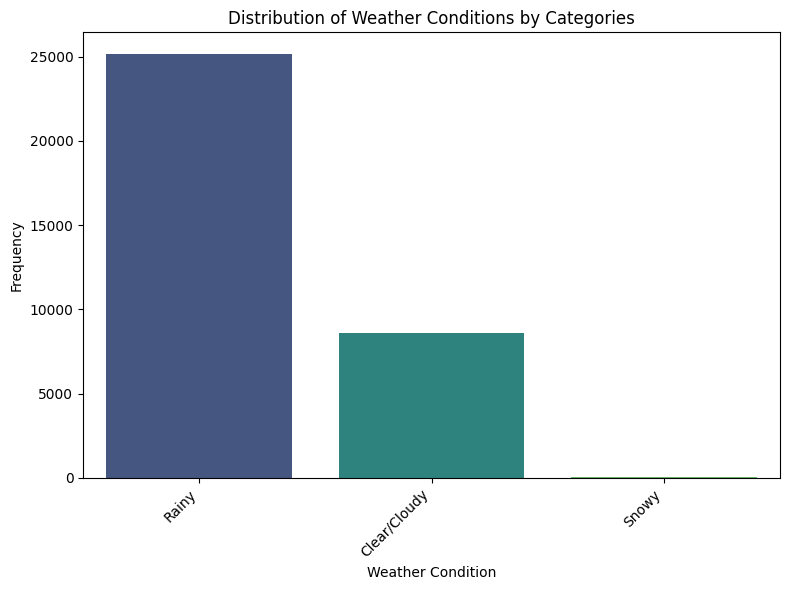

In [25]:
plt.figure(figsize=(8, 6))
sns.countplot(x='weather_condition_category', data=df_merged, palette='viridis', hue='weather_condition_category', legend=False)
plt.title('Distribution of Weather Conditions by Categories')
plt.xlabel('Weather Condition')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### **10.1.2 Average View Duration by Weather Condition**

This boxplot compares the average view duration (in seconds) across different weather conditions. We can see a clear trend: the median view duration is highest during 'Rainy' conditions, followed by 'Clear/Cloudy' conditions, and is shortest during 'Snowy' weather. This supports the hypothesis that rainy weather leads to higher user engagement, measured by how long users are viewing content.

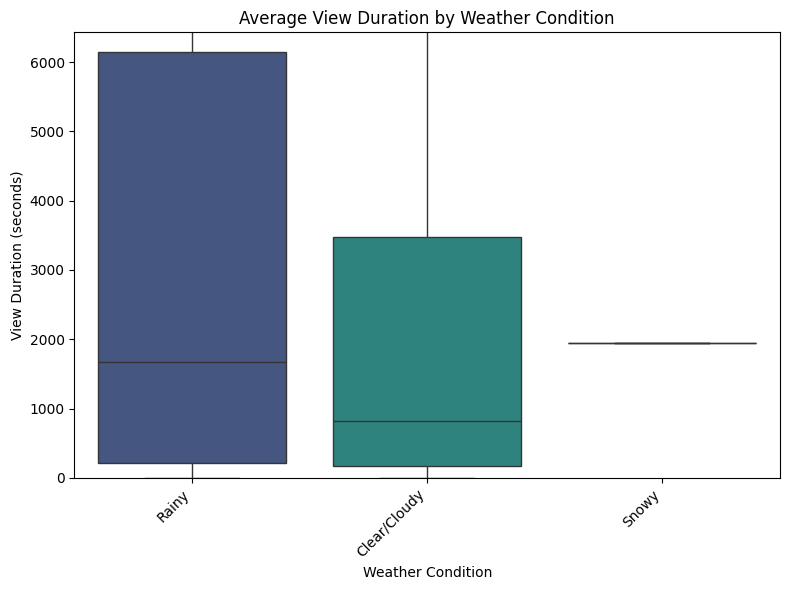

In [26]:
df_views = df_merged[df_merged['record_type'] == 'view'].copy()
    
plt.figure(figsize=(8, 6)) 
sns.boxplot(x='weather_condition_category', y='currenttime', data=df_views, hue='weather_condition_category', palette='viridis', legend=False)
plt.title('Average View Duration by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('View Duration (seconds)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, df_views['currenttime'].quantile(0.95)) 
plt.tight_layout()
plt.show()

#### **10.1.3 Average Purchase Amount by Weather Condition**

This boxplot examines the average purchase amount across different weather conditions. The median purchase amount is highest during 'Rainy' conditions. While there are some outliers, this visualization suggests that users tend to spend more on content during rainy weather, which could be a key insight for the variable pricing model.

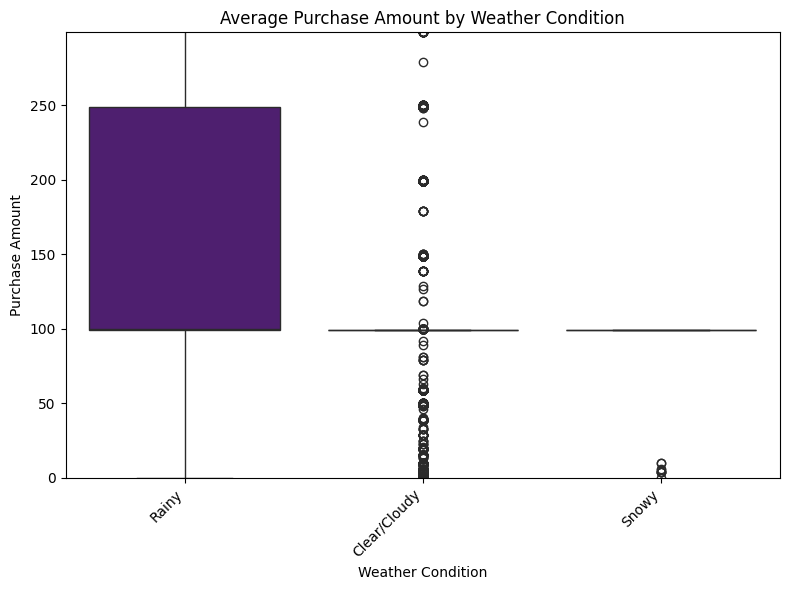

In [27]:
df_purchases = df_merged[df_merged['record_type'] == 'purchase'].copy()
    
plt.figure(figsize=(8, 6))
sns.boxplot(x='weather_condition_category', y='amount', data=df_purchases, hue='weather_condition_category', palette='magma', legend=False)
plt.title('Average Purchase Amount by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Purchase Amount')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, df_purchases['amount'].quantile(0.95)) 
plt.tight_layout()
plt.show()

#### **10.1.4 Views & Purchases in correlation to weather condition**

This grouped bar chart visualizes the count of view and purchase records across different weather conditions. We can observe that both views and purchases are most frequent during 'Rainy' conditions. Purchases significantly outnumber views in all weather categories, which aligns with the overall record type distribution. This visualization suggests a strong correlation between rainy weather and increased user activity on the platform.

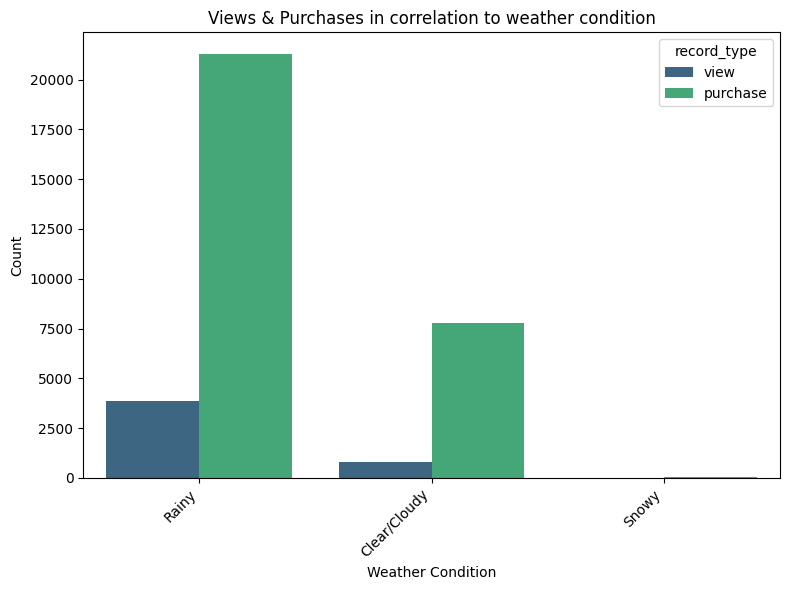

In [28]:
plt.figure(figsize=(8, 6)) 
sns.countplot(x='weather_condition_category', hue='record_type', data=df_merged, palette='viridis')
plt.title('Views & Purchases in correlation to weather condition')
plt.xlabel('Weather Condition')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### **10.2 Country Code Distribution**
This check helps us understand where our users are located. We'll display all of the countries to avoid truncation.

In [29]:
# Set option to display all rows for value counts
pd.set_option('display.max_rows', None)

# Checking value count for country_code
print("Value counts for 'country_code':")
print(df_merged['country_code'].value_counts())

Value counts for 'country_code':
country_code
KE    31238
NG      537
US      516
NZ      202
UG      175
TZ      145
RW      139
GB      121
AE       79
CA       72
IN       68
QA       51
DE       50
AU       46
FR       42
ZA       40
NL       28
SA       28
CH       23
GH       15
BE       15
TH       10
SE       10
ET        9
IT        9
SI        8
LB        8
RO        7
HR        6
KY        6
KW        6
TR        6
MU        6
NO        6
SC        6
JP        5
IE        5
SS        5
SO        5
BH        4
UA        4
BW        4
MW        4
SG        4
ZW        4
CD        3
GR        3
PL        3
CG        2
HU        2
HK        2
EG        2
AT        2
IQ        2
DJ        2
ZM        2
MX        2
GA        2
BI        2
RS        2
ES        2
JE        2
DZ        2
FI        2
ID        2
IL        2
BR        1
MZ        1
PH        1
SN        1
NA        1
MR        1
ML        1
CM        1
AL        1
OM        1
GY        1
EE        1
DK        1
PK    

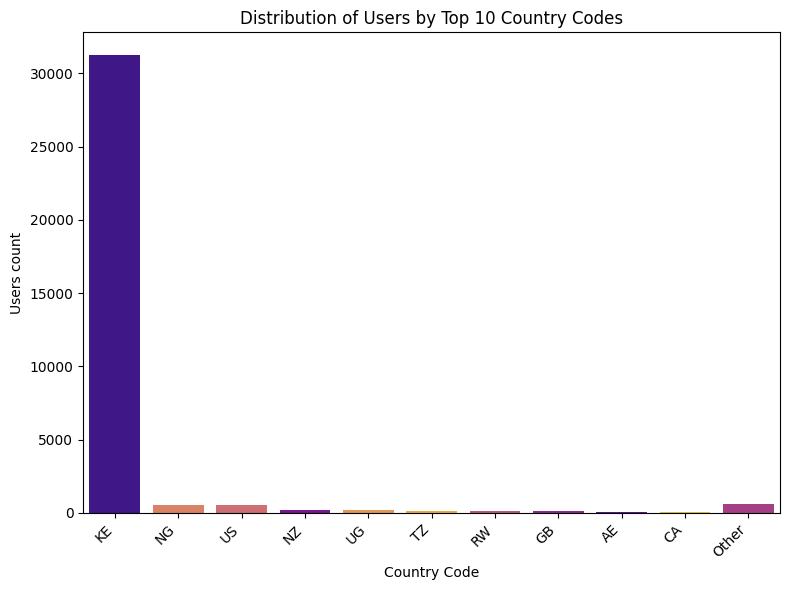

In [30]:
 # Calculate value counts for country codes
country_counts = df_merged['country_code'].value_counts()

 # Define N for top countries 
N = 10 
top_countries = country_counts.head(N).index
    
    # Create a new DataFrame for plotting, including Other category
df_plot_countries = df_merged.copy()
df_plot_countries['country_code_grouped'] = df_plot_countries['country_code'].apply(lambda x: x if x in top_countries else 'Other')

plt.figure(figsize=(8, 6)) 
sns.countplot(x='country_code_grouped', data=df_plot_countries, palette='plasma', 
                  order=top_countries.tolist() + ['Other'] if 'Other' in df_plot_countries['country_code_grouped'].unique() else top_countries.tolist(),
                  hue='country_code_grouped', legend=False) 
plt.title(f'Distribution of Users by Top {N} Country Codes')
plt.xlabel('Country Code')
plt.ylabel('Users count')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()
    

**Output Summary:**

The output reveals a large number of unique country codes, with a high concentration of users in countries like KEN (Kenya), ZAF (South Africa), and NGA (Nigeria). This geographical diversity suggests that the model should be robust enough to handle varying local contexts.

#### **10.3 Purchase Type Distribution**
This check helps us understand what types of purchases are most common on the platform.

In [31]:
# Checking value count for purchase_type
print("Value counts for 'purchase_type':")
print(df_merged['purchase_type'].value_counts())

Value counts for 'purchase_type':
purchase_type
RENTAL                       18697
PVOD                          6203
N/A                           4690
EST                           2406
SCREENING                      576
ZOOM SCREENING                 549
REGULAR OFFLINE SCREENING      239
OFFLINE SCREENING              159
BULK OFFLINE SCREENING         101
DUO OFFLINE SCREENING           79
TRIO OFFLINE SCREENING          34
MONO OFFLINE SCREENING          29
COUPLE OFFLINE SCREENING        27
OFFLINE SCREENIN                23
DOOR OFFLINE SCREENING           7
STUDENT OFFLINE SCREENING        5
SCREENING (DUO)                  5
SQUAD OFFLINE SCREENING          4
GETUP KENYA 2024                 3
GROUP OFFLINE SCREENING          2
UPSELL TO EST                    1
Name: count, dtype: int64


**Output Summary:**

The output shows that `Rental` is the most common purchase type, accounting for the majority of transactions. This is followed by `SVOD` (Subscription Video on Demand). This indicates that the platform's user base heavily favors renting content over subscribing.

#### **10.4. Temporal Trends in User Activity**
We will visualize user activity over time to identify any trends or seasonal patterns. This is a crucial step in understanding how user behavior changes over time.

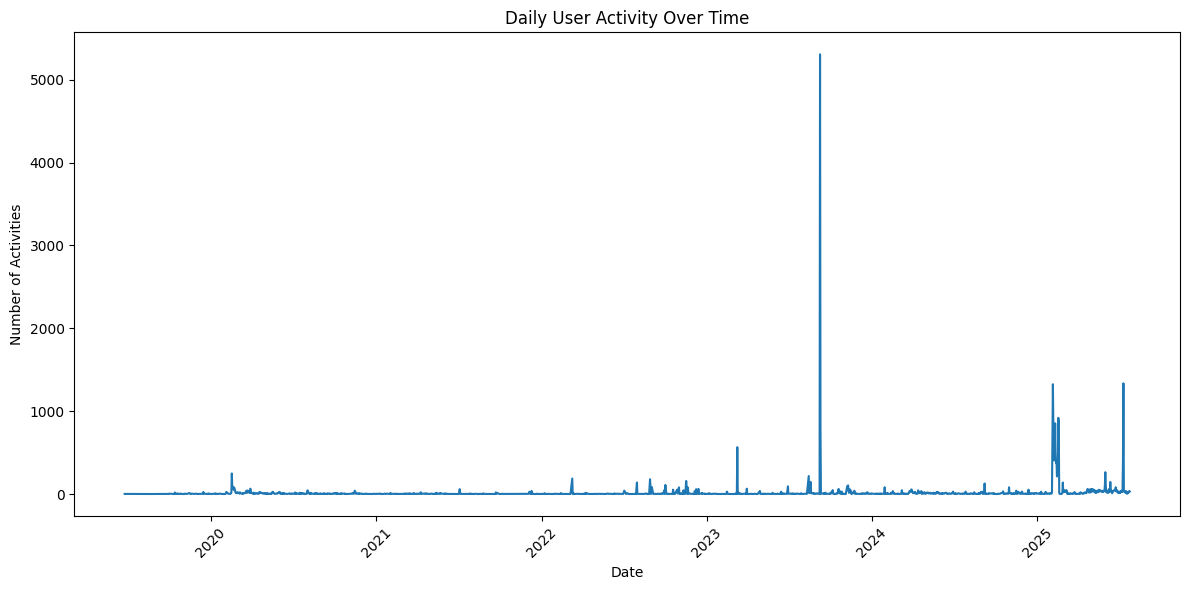

In [32]:
# Create a 'date' column without the time component
df_merged['date'] = pd.to_datetime(df_merged['activity_created_on']).dt.date
# Group by date and count the number of activities
daily_activity = df_merged.groupby('date').size().reset_index(name='activity_count')
# Plot the daily activity trend
plt.figure(figsize=(12, 6))
plt.plot(daily_activity['date'], daily_activity['activity_count'])
plt.title('Daily User Activity Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Activities')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Output Summary:**

The line plot illustrates the daily user activity over the captured time period. We can observe fluctuations in activity, suggesting that user engagement is not uniform. The spikes and dips may be related to specific events, days of the week, or, as we will explore next, weather patterns.

#### **10.5. Correlation of User Activity with Weather**
Now that we have a better understanding of the temporal trends in user activity, we will explore its correlation with key weather variables, such as temperature and precipitation. This is a core objective of the project.

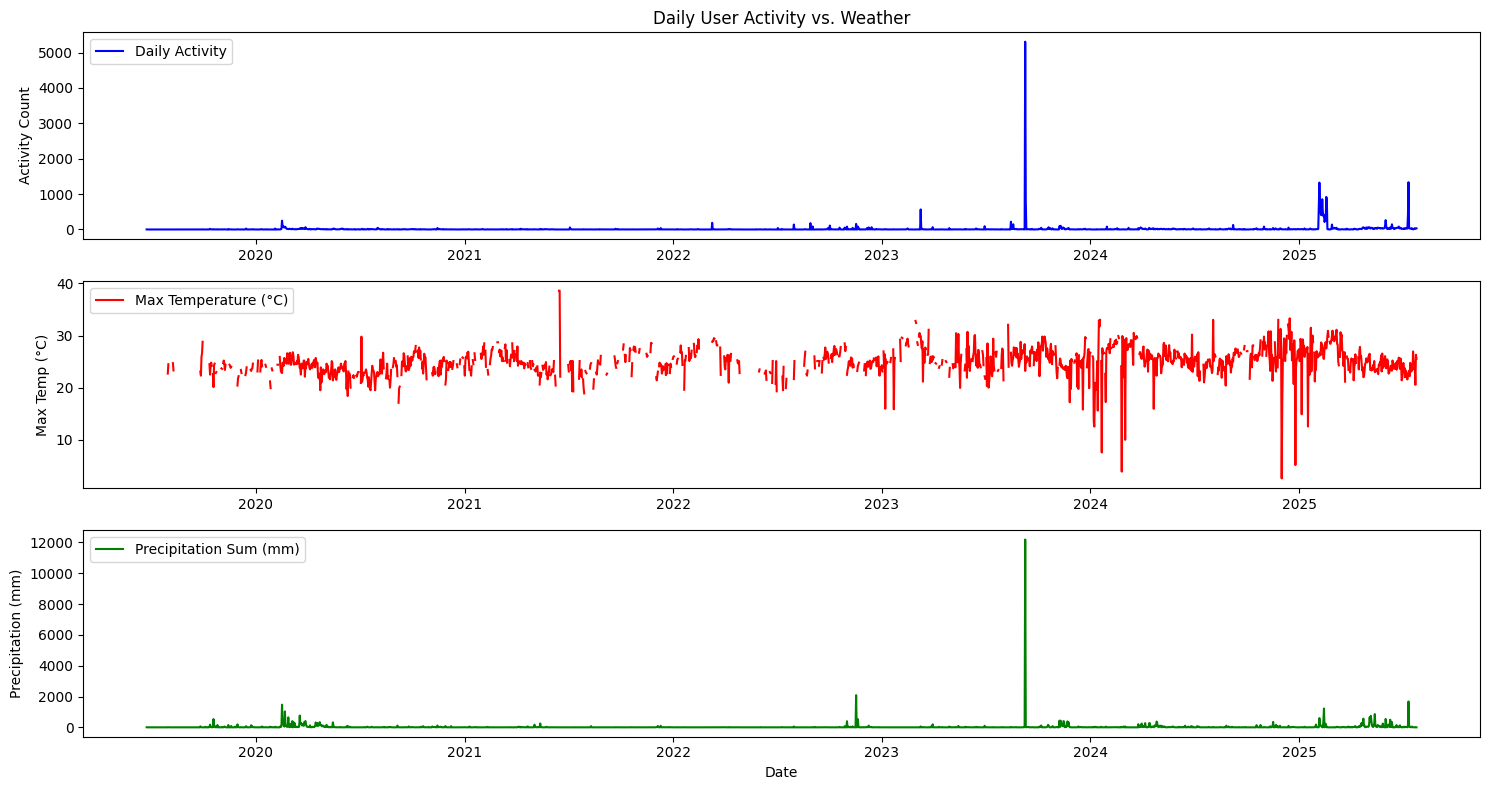

In [33]:
# Create a copy of the merged DataFrame and set a proper DatetimeIndex
df_temp = df_merged.copy()
df_temp['activity_created_on'] = pd.to_datetime(df_temp['activity_created_on'])
df_temp = df_temp.set_index('activity_created_on')

# Resample to daily frequency and aggregate
daily_data = df_temp.resample('D').agg({
    'record_type': 'size', # A robust way to count activities
    'temperature_2m_max': 'mean',
    'precipitation_sum': 'sum'
}).rename(columns={'record_type': 'activity_count'})

# Plotting the relationships
plt.figure(figsize=(15, 8))

# Plot Daily Activity Count
ax1 = plt.subplot(3, 1, 1)
ax1.plot(daily_data.index, daily_data['activity_count'], label='Daily Activity', color='blue')
ax1.set_title('Daily User Activity vs. Weather')
ax1.set_ylabel('Activity Count')
ax1.legend(loc='upper left')

# Plot Max Temperature
ax2 = plt.subplot(3, 1, 2, sharex=ax1)
ax2.plot(daily_data.index, daily_data['temperature_2m_max'], label='Max Temperature (°C)', color='red')
ax2.set_ylabel('Max Temp (°C)')
ax2.legend(loc='upper left')

# Plot Precipitation
ax3 = plt.subplot(3, 1, 3, sharex=ax1)
ax3.plot(daily_data.index, daily_data['precipitation_sum'], label='Precipitation Sum (mm)', color='green')
ax3.set_xlabel('Date')
ax3.set_ylabel('Precipitation (mm)')
ax3.legend(loc='upper left')

plt.tight_layout()
plt.show()

**Output Summary:**

The three plots provide a visual inspection of how daily user activity, maximum temperature, and total precipitation are related over time.

* **User Activity:** The top plot shows that user activity is not uniform over time. There are periods of low activity interspersed with occasional, significant spikes.
* **Temperature vs. Activity:** The middle plot shows the daily maximum temperature. While there are fluctuations, the temperature generally remains within a consistent range. There doesn't appear to be a strong, obvious correlation between temperature changes and the major spikes in user activity.
* **Precipitation vs. Activity:** The bottom plot shows precipitation. It's clear that precipitation is typically very low, with only a few significant rainfall events. A large spike in precipitation in late 2023 seems to coincide with a noticeable dip in user activity, suggesting a potential inverse relationship where heavy rain may deter user engagement. However, further analysis is needed to confirm this.

This visualization successfully highlights the a-temporal nature of user activity and its potential, albeit complex, relationship with weather patterns. The next steps in our EDA should involve a more quantitative approach to measuring these correlations.

#### **10.6. Correlation Heatmap of Numerical Features**
To quantify the relationships we observed visually and to identify any other potential correlations, we will compute and visualize the correlation matrix for our key numerical features. This includes weather metrics as well as engagement metrics.

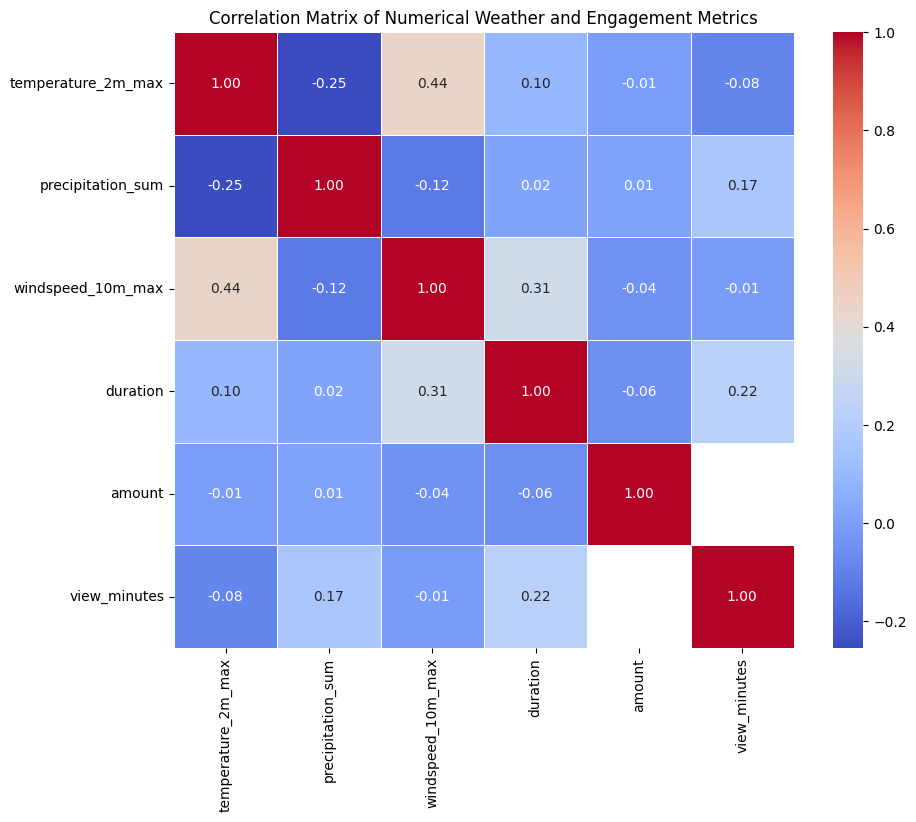

In [34]:
# Select the numerical columns for the correlation analysis
numerical_cols = ['temperature_2m_max', 'precipitation_sum', 'windspeed_10m_max', 'duration', 'amount', 'view_minutes']

# Create a correlation matrix
corr_matrix = df_merged[numerical_cols].corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Weather and Engagement Metrics')
plt.show()

**Output Summary:**

The correlation heatmap provides a quantitative view of the relationships between the selected numerical features.

* The strongest positive correlation is between `temperature_2m_max` and `windspeed_10m_max` at 0.44, suggesting that higher temperatures are moderately associated with stronger winds.
* We can also see a weak negative correlation of -0.25 between `temperature_2m_max` and `precipitation_sum`, which is expected as heavy rain often occurs on cooler days.
* `duration` has a moderate positive correlation with `windspeed_10m_max` at 0.31 and a weak positive correlation with `view_minutes` at 0.22.
* Notably, the `amount` of a purchase shows very weak correlations with all other variables, with values close to zero. This suggests that pricing is not strongly influenced by the weather or the content's duration.
* `view_minutes` has a weak correlation with most weather variables, with the highest being 0.17 with `precipitation_sum`.

This confirms our visual observations that while some relationships exist, they are generally weak, and factors other than those captured here may be more significant in driving user engagement and pricing.

#### **10.7. Histograms of Numerical Features**
To better understand the distribution of our key numerical variables, we'll create histograms. This visual representation helps us identify if the data is normally distributed, skewed, or if there are any outliers, which is crucial for selecting appropriate modeling techniques.

##### **10.7.1. Distribution of Maximum Temperature**

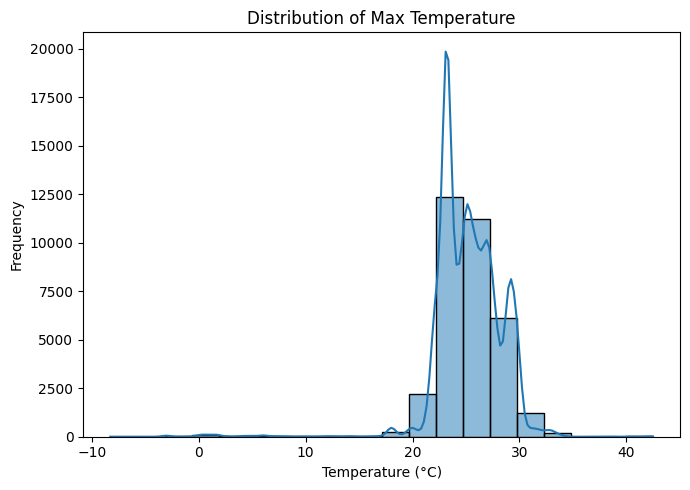

In [35]:
plt.figure(figsize=(7, 5))
sns.histplot(df_merged['temperature_2m_max'], kde=True, bins=20)
plt.title('Distribution of Max Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Output Summary:**

The histogram shows that the distribution of maximum temperatures is concentrated between 20°C and 30°C, with the most frequent temperatures falling around 25°C. The distribution appears to be slightly skewed to the left. The plot indicates that days with temperatures below 15°C or above 35°C are very rare in this dataset.

#### **10.7.2. Distribution of Maximum Wind Speed**

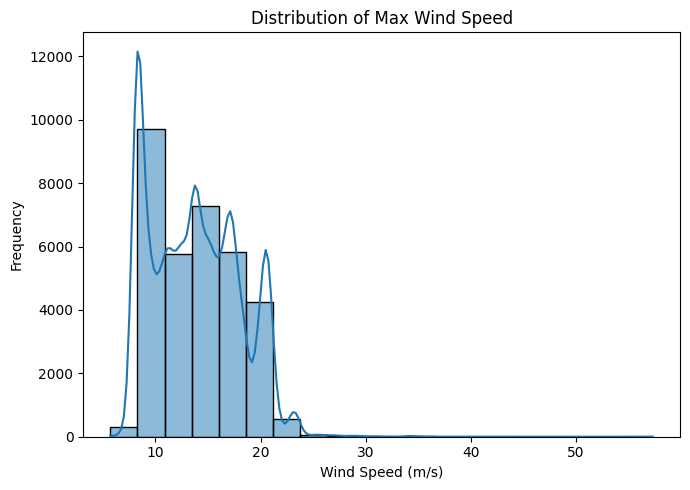

In [36]:
plt.figure(figsize=(7, 5))
sns.histplot(df_merged['windspeed_10m_max'], kde=True, bins=20)
plt.title('Distribution of Max Wind Speed')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Output Summary:**

The histogram for maximum wind speed is right-skewed, showing that the majority of wind speeds are low to moderate. The most frequent wind speeds are between 5 and 10 m/s, with a sharp drop in frequency for speeds above 20 m/s. This suggests that high wind speeds are an infrequent occurrence.

#### **10.7.3. Distribution of Precipitation Sum**

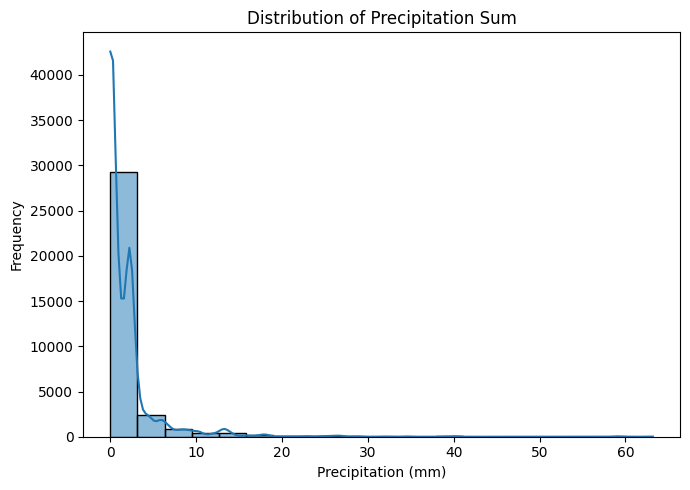

In [37]:
plt.figure(figsize=(7, 5))
sns.histplot(df_merged['precipitation_sum'], kde=True, bins=20)
plt.title('Distribution of Precipitation Sum')
plt.xlabel('Precipitation (mm)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Output Summary:**

The precipitation histogram is heavily skewed to the right, with a large concentration of data points at the lowest end of the scale. This indicates that the vast majority of days had little to no precipitation. The frequency drops sharply as precipitation increases, confirming that heavy rainfall events (over 10-20 mm) are rare in the dataset.

#### **10.8. Overall Genre Popularity**
This section establishes a baseline. Before we look at how weather affects genres, we need to know which genres are popular in general. This helps contextualize our findings.

Top 15 Most Popular Genres:
                                                Genre  Count
13                                           Trending  26735
2                                               Drama  20196
44                                    Movies by Women  19685
26                                         True Story  18886
1                                         Chick Flick  15549
9   Movies with Nominees of Women In Film Awards (...  14500
78                 Selected for Kitale Film Week 2024  10966
68                          Internationally Acclaimed  10548
24                                      Documentaries  10305
56  Movies to Watch this International Women's Month!   9707
67                                             Sports   9705
18                                           Suspense   9574
55                            Movies from Rift Valley   9450
36                                 Family Screen Time   8175
39                                           Religion   7

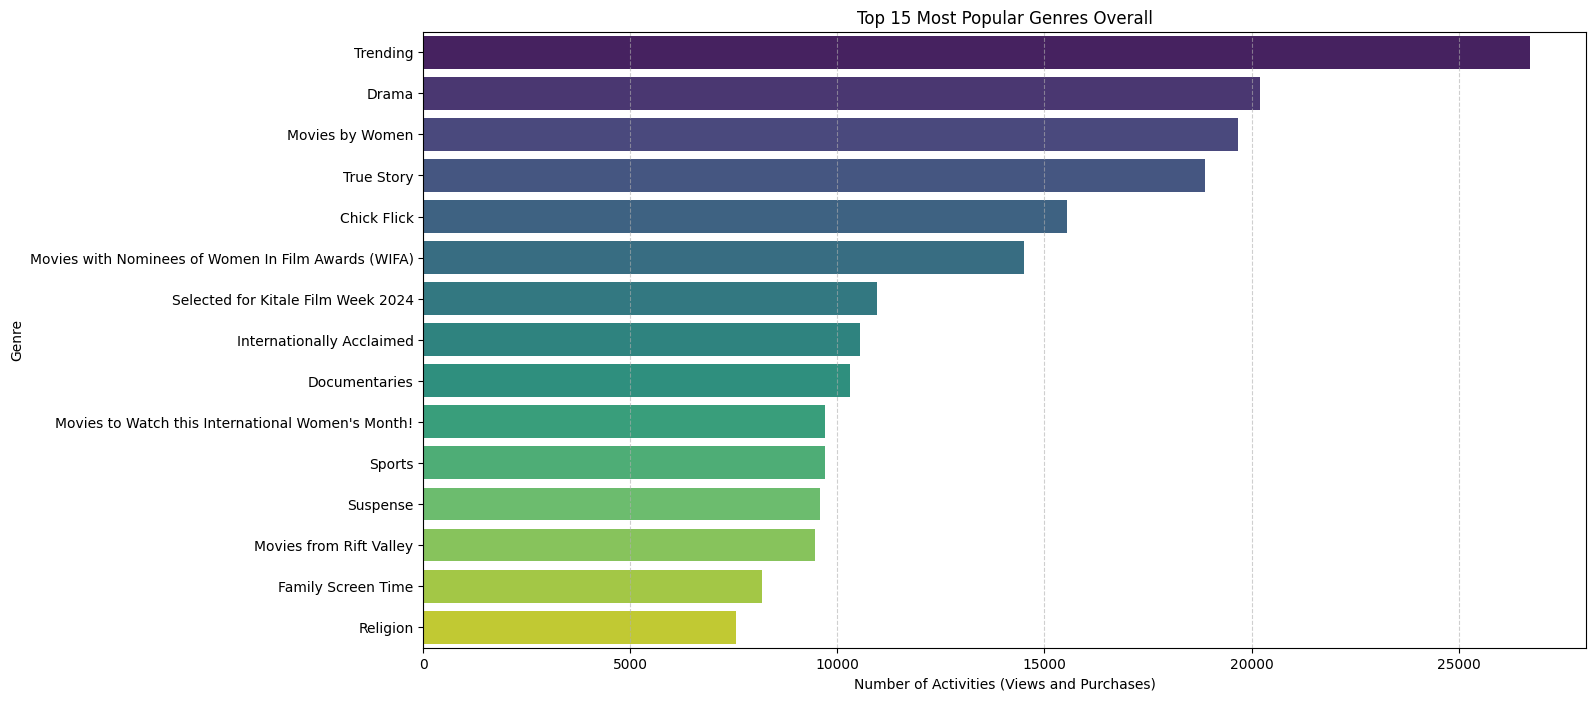

In [38]:
# Flatten the genres_list to analyze popularity
from collections import Counter

# Create a list of all genres
all_genres = [genre for sublist in df_merged['genres_list'].dropna() for genre in sublist]

# Count the occurrences of each genre
genre_counts = Counter(all_genres)

# Create a DataFrame from the genre counts for easy plotting
df_genre_counts = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values(by='Count', ascending=False)

# Display the top 15 most popular genres
print("Top 15 Most Popular Genres:")
print(df_genre_counts.head(15))

# Visualize the top genres
plt.figure(figsize=(15, 8))
sns.barplot(x='Count', y='Genre', data=df_genre_counts.head(15), palette='viridis')
plt.title('Top 15 Most Popular Genres Overall')
plt.xlabel('Number of Activities (Views and Purchases)')
plt.ylabel('Genre')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

**Output Summary:**

The bar chart now clearly shows that "Trending" is the most popular genre by a significant margin. This suggests that a large portion of user activity is driven by content that is currently popular on the platform, regardless of its specific genre. "Drama" and "Movies by Women" are the next most popular genres. This is a crucial insight for your content strategy.

#### **10.9. Genre Popularity by Weather Condition**
This is a direct response to a key project goal. We will see which genres are most popular during specific weather events like rain, and compare this to other conditions

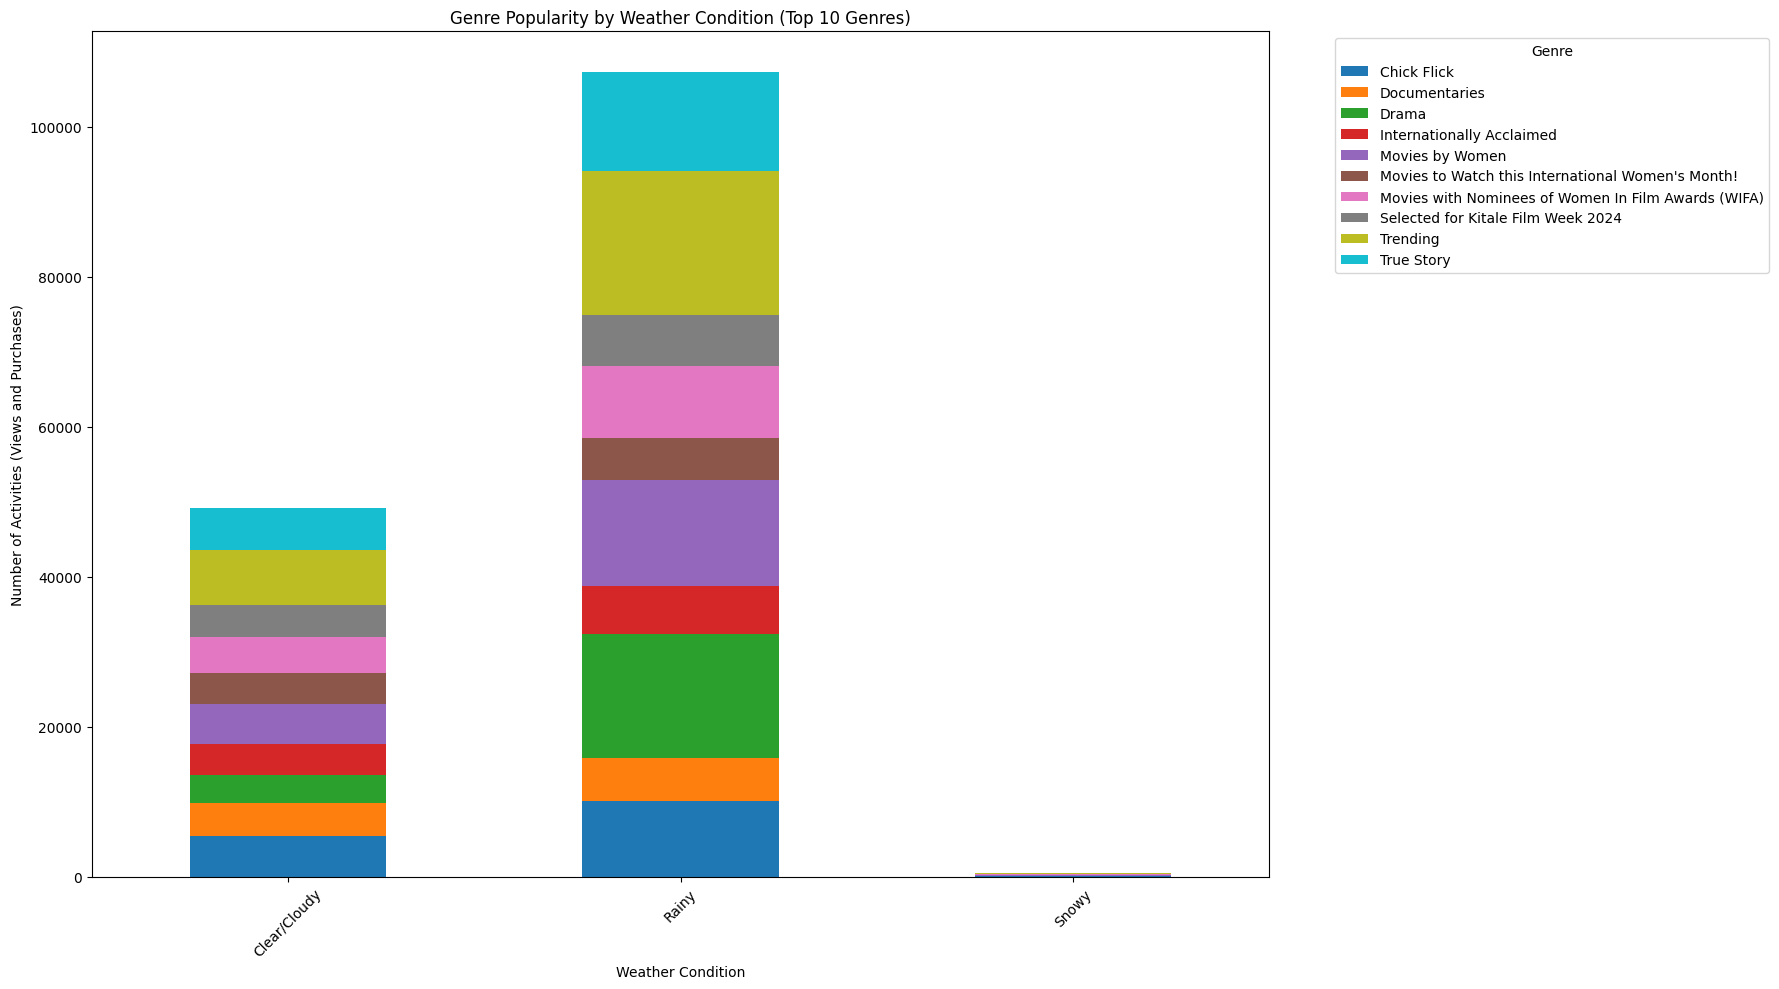

In [39]:
# Prepare the data for this analysis by "exploding" the genres_list column
# This creates a new row for each genre in the list, while duplicating the other column values.
df_genres_exploded = df_merged.explode('genres_list')

# Group by weather condition and genre, and count the occurrences
df_weather_genre_counts = df_genres_exploded.groupby(['weather_condition_category', 'genres_list']).size().reset_index(name='count')

# Get the top 10 overall genres for a cleaner visualization
top_genres = df_genre_counts.head(10)['Genre'].tolist()
df_pivot = df_weather_genre_counts[df_weather_genre_counts['genres_list'].isin(top_genres)].pivot_table(
    index='weather_condition_category', 
    columns='genres_list', 
    values='count', 
    fill_value=0
)

# Plot the stacked bar chart
df_pivot.plot(kind='bar', stacked=True, figsize=(18, 10))
plt.title('Genre Popularity by Weather Condition (Top 10 Genres)')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Activities (Views and Purchases)')
plt.xticks(rotation=45)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Output Summary:**

While "Trending" is the overall most popular, the stacked bar chart still shows that within the "Rainy" weather category, there is a notable increase in engagement with other genres like "Drama". This still supports the idea that specific genre preferences emerge during certain weather conditions, even when overall activity is dominated by "Trending" content.

#### **10.10. Genre Popularity by Temperature Range**
Similar to the weather conditions, this analysis will show how genre popularity shifts with temperature.

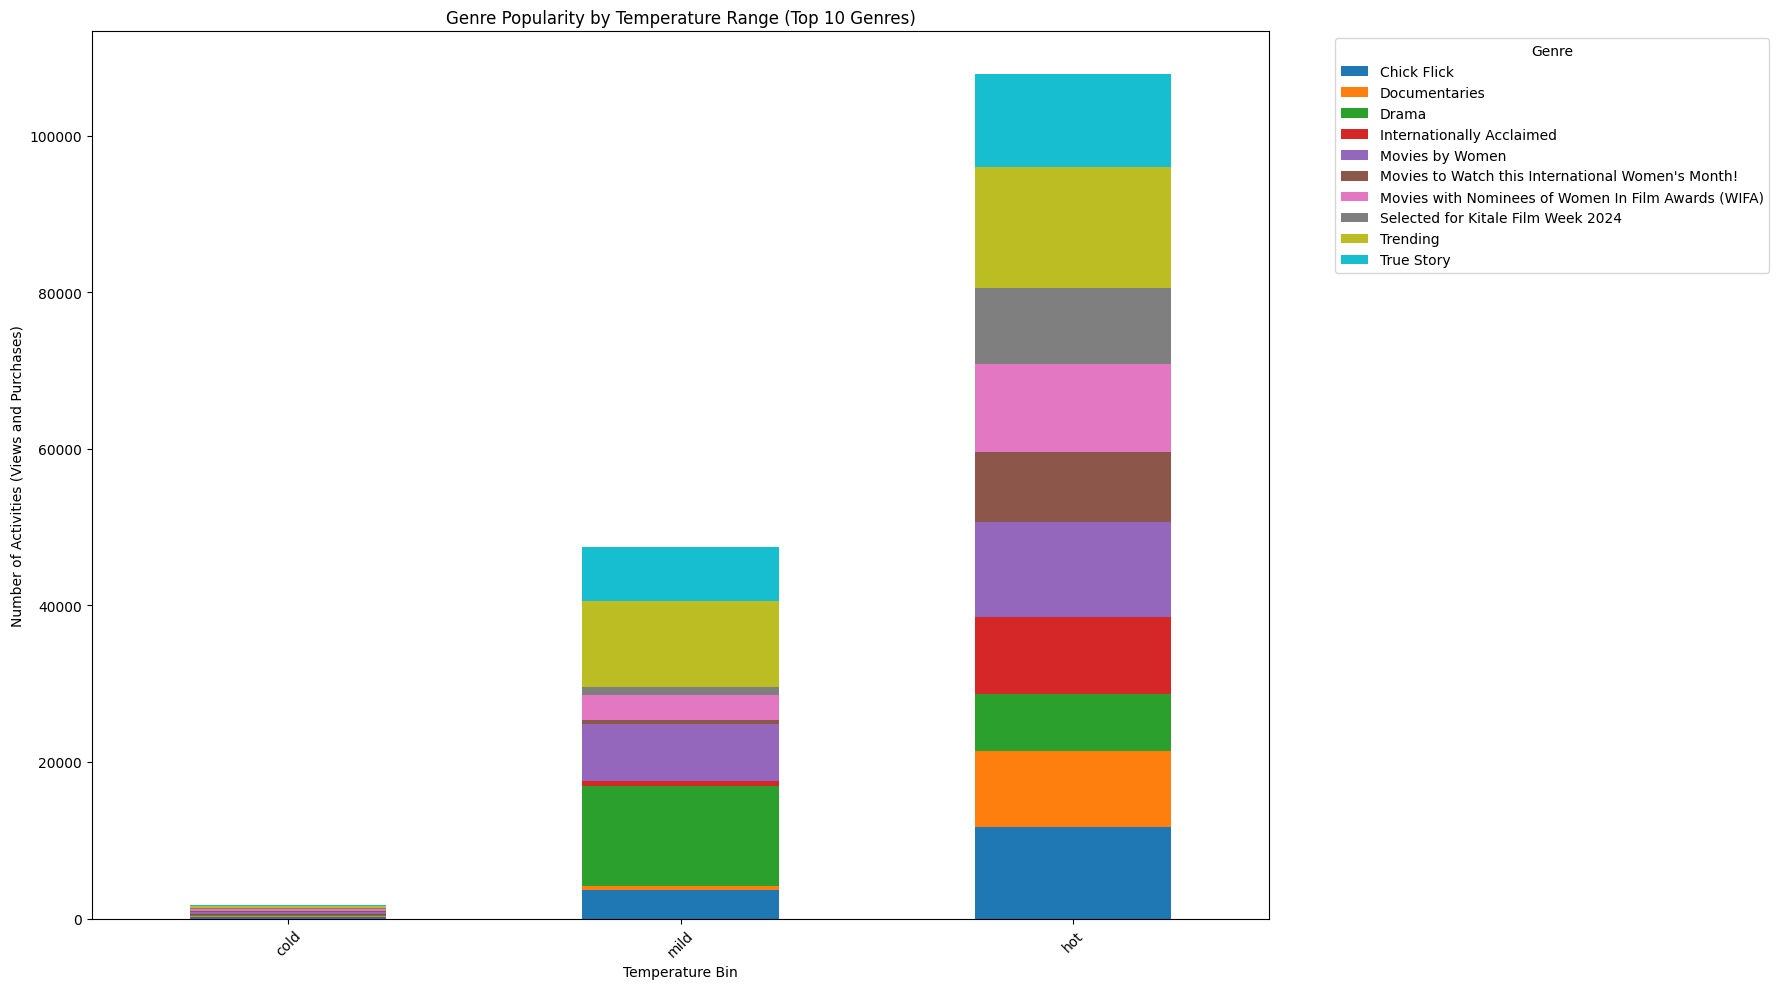

In [40]:
# Group by temperature bin and genre, then count
df_temp_genre_counts = df_genres_exploded.groupby(['temp_bin', 'genres_list']).size().reset_index(name='count')

# Pivot the table for plotting
df_temp_pivot = df_temp_genre_counts[df_temp_genre_counts['genres_list'].isin(top_genres)].pivot_table(
    index='temp_bin', 
    columns='genres_list', 
    values='count', 
    fill_value=0
)

# Plot the stacked bar chart
df_temp_pivot.plot(kind='bar', stacked=True, figsize=(18, 10))
plt.title('Genre Popularity by Temperature Range (Top 10 Genres)')
plt.xlabel('Temperature Bin')
plt.ylabel('Number of Activities (Views and Purchases)')
plt.xticks(rotation=45)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Output Summary:**

The chart continues to show that the "hot" temperature bin has the highest activity, and "Trending" is the most dominant genre within all temperature categories.

### **11.Predictive Modeling**
Now that we have cleaned, merged, and explored our data, the next crucial step is to build a predictive model. Our primary goal is to forecast periods of high and low demand so we can inform the variable pricing strategy. Based on the fact that viewing data spans multiple days, we'll first simulate daily viewing sessions to get a more granular view of user activity. We will then frame this as a classification problem: predicting whether a day will have a high or low demand.

## Conclusion

### Project Overview

This project explored how climate conditions affect user behavior on the MyMovies.Africa™ platform and how this insight can be used to drive intelligent, data-backed pricing decisions. By integrating historical weather data with user activity logs, the project aimed to forecast demand and simulate climate-sensitive pricing strategies that optimize revenue and user engagement.

The final solution combines time series modeling, machine learning classification, and real-time data visualization in a hybrid forecasting system deployed to the web via Vercel.

---
### Deployment Highlights

The model was deployed successfully to an interactive dashboard:

🔗 [Live Project](https://yakwetu-weather-dynamic-project.vercel.app/)

#### Key Features:
- **Real-Time Weather Integration**: Pulls current climate conditions and uses them to forecast demand and price dynamically.
- **7-Day Forecast Table**: Lists predicted weather, temperature, demand classification, and final price.
- **Hybrid Forecast Visuals**:
  - XGBoost demand bar charts
  - Prophet time series predictions
- **Dynamic Pricing Strategy Panel**: Visualizes pricing variation vs base price.
- **Pricing Calculator**: Allows users to simulate pricing outcomes based on temperature, weather conditions, and precipitation inputs.

This deployment transforms the data science output into a usable, real-time decision support system for marketing and pricing teams.

---

### Final Reflections

From early model experimentation to a refined hybrid forecasting engine and a full production deployment, this project demonstrates the application of data science in solving real-world business challenges. The solution is not only data-driven and explainable, but also actionable and production-ready — showcasing the entire data science lifecycle: from data wrangling and modeling to visualization and deployment.

This work affirms that weather and environmental factors have a meaningful impact on user behavior in digital platforms and that dynamic pricing, powered by machine learning, can enhance both user experience and platform profitability.